# Telco Customer Churn — Feature Engineering & Predictive Modeling

**Business problem:** A telecom company loses revenue every month to customer churn. This notebook builds a model that predicts, for each currently active customer, their probability of churning — so the business can intervene (retention offer, support outreach) *before* the customer leaves, not after.

**Dataset:** IBM/Kaggle Telco Customer Churn — 7,043 customers, 21 columns (19 features + `customerID` + `Churn` target). Source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Scope of this notebook:** EDA -> justified feature engineering -> preprocessing pipeline -> model training with MLflow experiment tracking -> model comparison & selection -> interpretability -> leakage sanity check.

Every technique used below is chosen *because the data justifies it*, not because it was available. Where a common alternative was **not** used, the reasoning is stated explicitly — this notebook doubles as the answer key for "why this, not that."


In [1]:
import sys
import platform

print("Python:", sys.version)
print("Architecture:", platform.machine())
print("Python executable:", sys.executable)

Python: 3.11.16 (main, Aug 12 2026, 23:03:19) [Clang 16.0.0 (clang-1600.0.26.6)]
Architecture: arm64
Python executable: /Users/arpitajadhav/Desktop/TelcoML/.venv/bin/python


In [2]:
import xgboost

print("XGBoost version:", xgboost.__version__)
print("XGBoost import successful!")

XGBoost version: 3.2.0
XGBoost import successful!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import mlflow
import mlflow.sklearn
import joblib
import shap
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Load & Inspect Data

In [4]:
df = pd.read_csv("/Users/arpitajadhav/Desktop/TelcoML/Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Exploratory Data Analysis (only what this dataset needs)

We deliberately keep EDA scoped to what the *modeling decisions downstream* actually depend on: class balance (-> metric & imbalance strategy), missingness pattern (-> imputation strategy), numeric distributions (-> transformation & scaling decisions), and categorical association with the target (-> feature selection). A full normality/homoscedasticity/scatter-plot regression-diagnostic workup is *not* run here because this is a classification problem with only 3 numeric predictors — that machinery belongs to linear regression diagnostics, not this task.

### 2.1 Target class balance

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


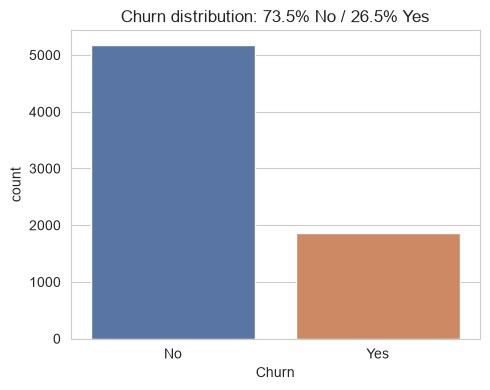

In [6]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)

fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette=['#4C72B0','#DD8452'], legend=False, ax=ax)
ax.set_title(f"Churn distribution: {churn_counts['No']:.1f}% No / {churn_counts['Yes']:.1f}% Yes")
plt.tight_layout()
plt.show()


**Decision:** 26.5% churn is a *moderate* imbalance, not severe. Severe imbalance (commonly cited threshold: <10% minority class) is where SMOTE-style synthetic oversampling is usually justified. Here, `class_weight='balanced'` is enough to make the model pay attention to the minority class, without introducing synthetic (fabricated) customer records into a business-facing model that needs to stay fully explainable. This is also why **Recall and ROC-AUC**, not raw Accuracy, will be the primary metrics — a model that predicts "No churn" for everyone would still get ~73% accuracy while being useless for the actual business goal.

### 2.2 Fixing `TotalCharges` and checking real missingness

In [7]:
# TotalCharges was loaded as text — check why
print(df['TotalCharges'].dtype)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after coercion:", df['TotalCharges'].isna().sum())

missing_rows = df[df['TotalCharges'].isna()]
print("\ntenure values for the missing rows:")
print(missing_rows['tenure'].unique())


str
Missing TotalCharges after coercion: 11

tenure values for the missing rows:
[0]


**Finding:** All 11 missing `TotalCharges` values belong to customers with `tenure = 0` — i.e. brand-new customers who haven't been billed yet. This is not random missingness (MCAR); it has a known, explainable cause.

**Decision — conditional impute, not mean/median fill:** Filling with the column median would invent a spend history for a customer who has none. The logically correct value is `0`, because tenure=0 customers genuinely haven't been charged anything yet. This mirrors the mindmap's own "Conditional impute" pattern — using the *context* of the row (tenure bucket) to decide the fill, not a blanket global statistic.

In [8]:
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0.0
assert df['TotalCharges'].isna().sum() == 0
print("Missing values remaining:", df.isna().sum().sum())


Missing values remaining: 0


### 2.3 Numeric feature distributions, skew, and outliers

tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963235
dtype: float64


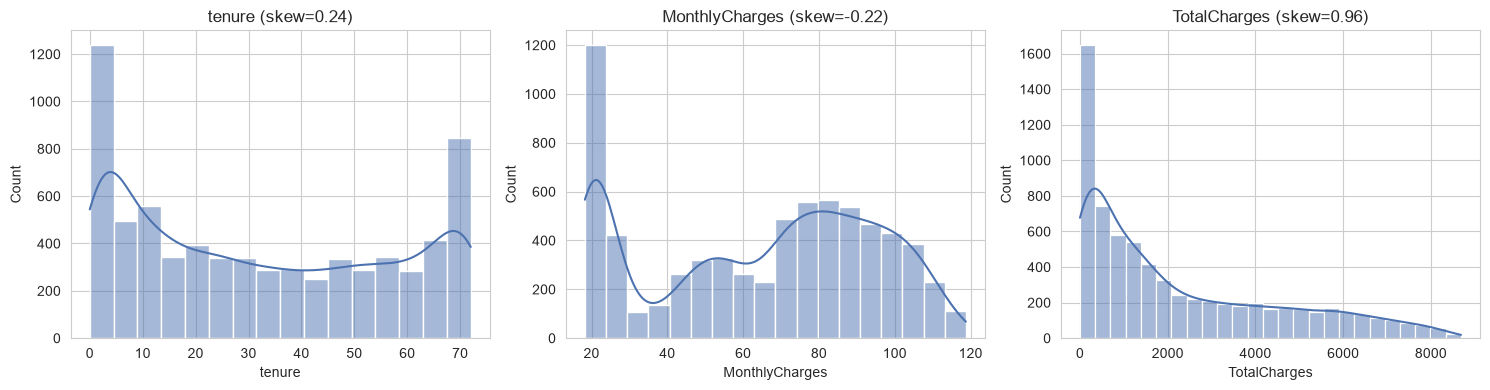

In [9]:
numeric_raw = ['tenure', 'MonthlyCharges', 'TotalCharges']
skews = df[numeric_raw].skew()
print(skews)

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, numeric_raw):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f"{col} (skew={skews[col]:.2f})")
plt.tight_layout()
plt.show()


**Decision — log-transform only `TotalCharges`, leave the other two raw:** `tenure` (skew ≈0.24) and `MonthlyCharges` (skew ≈-0.22) are close to symmetric — transforming them would add noise, not remove it. `TotalCharges` (skew ≈0.96) is moderately right-skewed. We'll handle this via the collinearity finding below rather than a separate log-transform, since `TotalCharges` turns out to be redundant anyway.

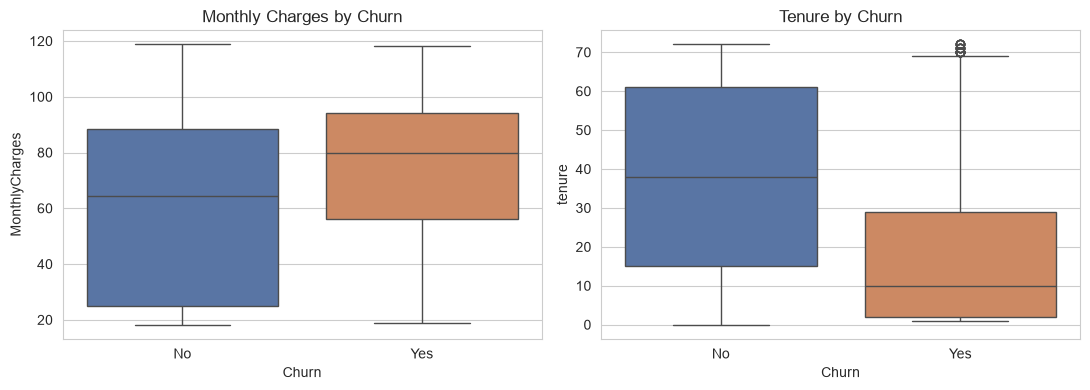

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette=['#4C72B0','#DD8452'], legend=False, ax=axes[0])
axes[0].set_title("Monthly Charges by Churn")
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette=['#4C72B0','#DD8452'], legend=False, ax=axes[1])
axes[1].set_title("Tenure by Churn")
plt.tight_layout()
plt.show()


No extreme outliers requiring capping/winsorizing are present — charges are naturally bounded by the company's own pricing plans (max ~118), and tenure is bounded 0-72 months by the data collection window. Outlier treatment from the ML syllabus (capping/flooring/winsorizing) is **not applied** because there's nothing pathological to treat — applying it anyway would just be checkbox behavior with no justification.

### 2.4 Multicollinearity check: is `TotalCharges` actually new information?

corr(TotalCharges, tenure x MonthlyCharges) = 0.9996
corr(TotalCharges, tenure)                   = 0.8262
corr(TotalCharges, MonthlyCharges)            = 0.6512


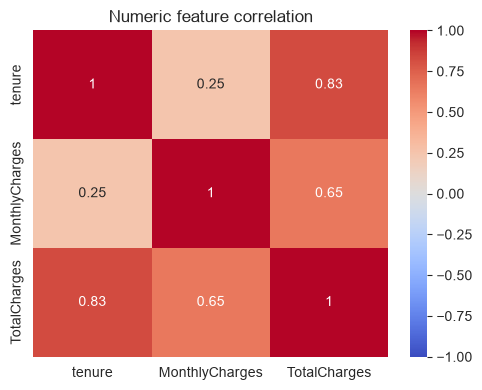

In [11]:
corr_tc_calc = np.corrcoef(df['TotalCharges'], df['tenure'] * df['MonthlyCharges'])[0,1]
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {corr_tc_calc:.4f}")
print(f"corr(TotalCharges, tenure)                   = {df['TotalCharges'].corr(df['tenure']):.4f}")
print(f"corr(TotalCharges, MonthlyCharges)            = {df['TotalCharges'].corr(df['MonthlyCharges']):.4f}")

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title("Numeric feature correlation")
plt.tight_layout()
plt.show()


**Finding:** `TotalCharges` correlates **0.9996** with `tenure x MonthlyCharges` — it is, for practical purposes, a derived duplicate of two features we already have.

**Decision — drop `TotalCharges`, keep `tenure` and `MonthlyCharges`:** This maps directly to the mindmap's "Correlation filter — near-duplicate copy, drop one" pattern. Keeping all three would (a) destabilize Logistic Regression's coefficients through multicollinearity, and (b) split feature-importance/SHAP credit between duplicate signals, making the interpretability story muddier for no accuracy gain. We instead engineer `avg_monthly_spend` below, which captures similar information more robustly.

### 2.5 Categorical features vs Churn — Chi-square filter

In [12]:
cat_cols = df.select_dtypes(include='object').drop(columns=['customerID','Churn']).columns.tolist()

chi_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi_results.append((col, chi2, p))

chi_df = pd.DataFrame(chi_results, columns=['feature','chi2_stat','p_value']).sort_values('p_value')
chi_df['significant_at_0.05'] = chi_df['p_value'] < 0.05
chi_df


,feature,chi2_stat,p_value,significant_at_0.05
12,Contract,1184.596572,5.863038e-258,True
6,OnlineSecurity,849.998968,2.661150e-185,True
9,TechSupport,828.197068,1.443084e-180,True
5,InternetService,732.309590,9.571788e-160,True
14,PaymentMethod,648.142327,3.682355e-140,True
7,OnlineBackup,601.812790,2.079759e-131,True
8,DeviceProtection,558.419369,5.505219e-122,True
11,StreamingMovies,375.661479,2.667757e-82,True
10,StreamingTV,374.203943,5.528994e-82,True
13,PaperlessBilling,258.277649,4.073355e-58,True


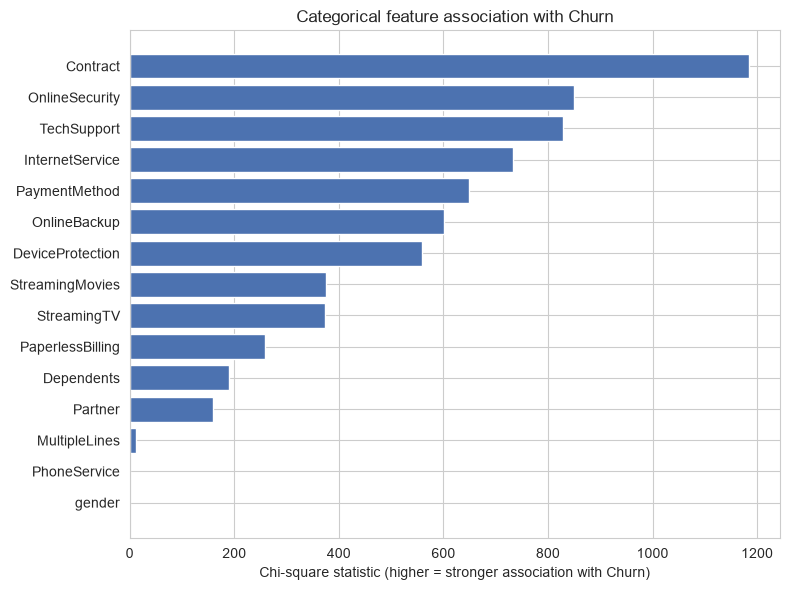

In [13]:
fig, ax = plt.subplots(figsize=(8,6))
chi_df_sorted = chi_df.sort_values('chi2_stat')
ax.barh(chi_df_sorted['feature'], chi_df_sorted['chi2_stat'], color='#4C72B0')
ax.set_xlabel("Chi-square statistic (higher = stronger association with Churn)")
ax.set_title("Categorical feature association with Churn")
plt.tight_layout()
plt.show()


**Decision — Chi-square filter, not RFE:** Every categorical feature here shows p < 0.05 (statistically associated with churn), so nothing gets dropped outright at this stage — the filter instead tells us *which* features (`Contract`, `OnlineSecurity`, `TechSupport`, `InternetService`) carry the strongest signal, which we'll cross-check against the trained models' own feature importance later. A wrapper method like RFE was intentionally skipped: with our final feature count staying under ~25 after encoding, RFE's repeated retraining (mindmap: *"RFE retrains the model 10 times; a filter test runs once"*) buys accuracy we don't need at a compute cost we don't need to pay.

## 3. Feature Engineering

Dropping `customerID` first — it is a unique identifier with zero predictive signal and a classic case of a column that *looks* like data but is actually noise (a direct instance of the mindmap's leakage-awareness principle, even though this particular column isn't a leakage risk so much as a non-feature).

In [14]:
df_fe = df.drop(columns=['customerID']).copy()


### 3.1 Business/behavioral features (RFM-style)

Directly inspired by the mindmap's "Business Features" card (RFM features, behavioral aggregates). These aren't generic polynomial expansions — each one encodes a specific business intuition about churn risk:

- **`tenure_bucket`**: churn risk is famously front-loaded in subscription businesses — new customers churn far more than loyal ones. Bucketing lets tree models split on this non-linearly and gives Logistic Regression an explicit non-linear signal it otherwise can't see from raw `tenure` alone.
- **`total_services`**: a behavioral aggregate — customers with more add-on services subscribed are more "locked in" and switching-cost-averse.
- **`avg_monthly_spend`**: replaces the redundant `TotalCharges` with a normalized version (`total spend / tenure`) that's comparable across customers regardless of how long they've been a customer.

Polynomial/interaction feature expansion (also in the mindmap) was **not** used — with a small, already-informative feature set, blind polynomial expansion risks the mindmap's own "curse of dimensionality — too many new features, too sparse" warning, and tree models (Random Forest, XGBoost) already capture feature interactions natively without needing them spelled out.

In [15]:
def tenure_bucket(t):
    if t <= 12: return "0-1yr"
    elif t <= 24: return "1-2yr"
    elif t <= 48: return "2-4yr"
    else: return "4yr+"

df_fe['tenure_bucket'] = df_fe['tenure'].apply(tenure_bucket)

service_cols = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
                 'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

def count_services(row):
    return sum(1 for c in service_cols if row[c] not in ['No', 'No phone service', 'No internet service'])

df_fe['total_services'] = df_fe.apply(count_services, axis=1)
df_fe['avg_monthly_spend'] = df_fe['TotalCharges'] / df_fe['tenure'].replace(0, 1)

# drop the near-duplicate identified in 2.4
df_fe = df_fe.drop(columns=['TotalCharges'])

print(df_fe.shape)
df_fe[['tenure','tenure_bucket','total_services','avg_monthly_spend']].head()


(7043, 22)


,tenure,tenure_bucket,total_services,avg_monthly_spend
0,1,0-1yr,2,29.850000
1,34,2-4yr,4,55.573529
2,2,0-1yr,4,54.075000
3,45,2-4yr,4,40.905556
4,2,0-1yr,2,75.825000


### 3.2 Leakage sanity check

Mindmap's own detection checklist: *"could this feature have existed at prediction time?"* Walking every engineered/raw feature through that question:

| Feature | Knowable at prediction time? | Verdict |
|---|---|---|
| `tenure`, `MonthlyCharges` | Yes — known the moment you're scoring an active customer | Safe |
| `Contract`, `PaymentMethod`, service flags | Yes — current account state | Safe |
| `avg_monthly_spend`, `total_services`, `tenure_bucket` | Yes — derived purely from the above | Safe |
| *(hypothetical)* `CancellationDate` | **No** — only exists after the customer has already churned | Would be target leakage — not present in this dataset, but this is exactly the trap the mindmap's own example warns about |

No leakage-risk columns are present in this dataset after dropping `customerID`.

## 4. Preprocessing Pipeline

Two separate `ColumnTransformer` pipelines are built deliberately, not one:

- **Scaled pipeline** (`StandardScaler` + encoding) — for Logistic Regression, which is distance/gradient-sensitive to feature scale.
- **Unscaled pipeline** (passthrough + encoding) — for Random Forest / XGBoost, which split on raw thresholds and are scale-invariant (mindmap: *"KNN needs scaling; Decision Tree doesn't"*).

Both use `OneHotEncoder` for all categorical columns (binary and multi-category alike, via `drop='if_binary'` which collapses true binary columns to a single 0/1 column). Target/mean encoding was **not** used — with only 2-4 categories per column, one-hot doesn't cause a dimensionality problem, and target encoding introduces its own leakage risk (mindmap: *"Leakage risk — compute average from TRAIN rows only"*) that isn't worth taking for zero benefit here.

The train/test split happens **before** any fitting, and every transformer below is `fit()` only on the training fold — this is the direct fix for the mindmap's "Preprocessing leakage — scaler fit on train+test combined" warning.

In [16]:
target = df_fe['Churn'].map({'Yes': 1, 'No': 0})
X = df_fe.drop(columns=['Churn'])
y = target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(3), " Test churn rate:", y_test.mean().round(3))


Train: (5634, 21)  Test: (1409, 21)
Train churn rate: 0.265  Test churn rate: 0.265


In [17]:
numeric_features = ['tenure', 'MonthlyCharges', 'avg_monthly_spend', 'total_services', 'SeniorCitizen']
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor_scaled = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
])

preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['tenure', 'MonthlyCharges', 'avg_monthly_spend', 'total_services', 'SeniorCitizen']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_bucket']


## 5. Model Training & MLflow Experiment Tracking

Three classifiers are trained and logged to MLflow: **Logistic Regression** (interpretable baseline), **Random Forest**, and **XGBoost**. All three use class-imbalance handling (`class_weight='balanced'` / `scale_pos_weight`) rather than SMOTE, per the reasoning in section 2.1.

Metrics tracked: Accuracy, Precision, Recall, F1, ROC-AUC — with **Recall and ROC-AUC prioritized** for model selection, since missing a would-be churner (false negative) costs the business a lost customer, while a false positive just costs a retention offer the customer didn't strictly need.

In [18]:
mlflow.set_tracking_uri("sqlite:///../mlruns.db")
mlflow.set_experiment("telco_churn_prediction")

def evaluate(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_proba)
    }

results = {}
fitted_pipelines = {}


In [19]:
# --- Logistic Regression ---
with mlflow.start_run(run_name="logistic_regression") as run:
    params = {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 1000}
    pipe = Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', LogisticRegression(**params))
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    m = evaluate(y_test, pred, proba)

    mlflow.log_params({**params, 'model_type': 'LogisticRegression'})
    mlflow.log_metrics(m)
    mlflow.sklearn.log_model(pipe, name="model", serialization_format="pickle")

    results['LogisticRegression'] = m
    fitted_pipelines['LogisticRegression'] = pipe
    lr_run_id = run.info.run_id
    print("Logistic Regression:", m)


2026/09/25 18:56:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression: {'accuracy': 0.7331440738112136, 'precision': 0.49830508474576274, 'recall': 0.786096256684492, 'f1': 0.6099585062240664, 'roc_auc': 0.8411583869384381}


In [20]:
# --- Random Forest ---
with mlflow.start_run(run_name="random_forest") as run:
    params = {'n_estimators': 300, 'max_depth': 12, 'class_weight': 'balanced', 'random_state': RANDOM_STATE}
    pipe = Pipeline([
        ('prep', preprocessor_tree),
        ('clf', RandomForestClassifier(**params))
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    m = evaluate(y_test, pred, proba)

    mlflow.log_params({**params, 'model_type': 'RandomForest'})
    mlflow.log_metrics(m)
    mlflow.sklearn.log_model(pipe, name="model", serialization_format="pickle")

    results['RandomForest'] = m
    fitted_pipelines['RandomForest'] = pipe
    rf_run_id = run.info.run_id
    print("Random Forest:", m)


2026/09/25 18:57:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest: {'accuracy': 0.7551454932576295, 'precision': 0.5289421157684631, 'recall': 0.7085561497326203, 'f1': 0.6057142857142858, 'roc_auc': 0.8307887054690124}


In [21]:
# --- XGBoost ---
with mlflow.start_run(run_name="xgboost") as run:
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    params = {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05,
              'scale_pos_weight': scale_pos_weight, 'random_state': RANDOM_STATE}
    pipe = Pipeline([
        ('prep', preprocessor_tree),
        ('clf', XGBClassifier(**params, eval_metric='logloss'))
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    m = evaluate(y_test, pred, proba)

    mlflow.log_params({**params, 'model_type': 'XGBoost'})
    mlflow.log_metrics(m)
    mlflow.sklearn.log_model(pipe, name="model", serialization_format="pickle")

    results['XGBoost'] = m
    fitted_pipelines['XGBoost'] = pipe
    xgb_run_id = run.info.run_id
    print("XGBoost:", m)


2026/09/25 18:57:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost: {'accuracy': 0.7530163236337828, 'precision': 0.5241635687732342, 'recall': 0.7540106951871658, 'f1': 0.618421052631579, 'roc_auc': 0.8374318633909428}


## 6. Model Comparison & Selection

In [22]:
results_df = pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)
results_df.style.format("{:.4f}").background_gradient(cmap='Greens', subset=['roc_auc','recall'])


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.7331,0.4983,0.7861,0.6100,0.8412
XGBoost,0.7530,0.5242,0.7540,0.6184,0.8374
RandomForest,0.7551,0.5289,0.7086,0.6057,0.8308


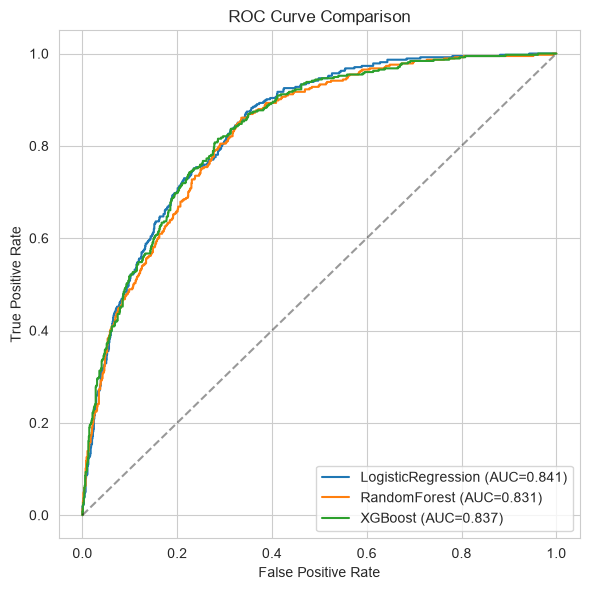

In [23]:
fig, ax = plt.subplots(figsize=(6,6))
for name, pipe in fitted_pipelines.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = results[name]['roc_auc']
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()


In [24]:
best_model_name = results_df.index[0]
best_pipeline = fitted_pipelines[best_model_name]
print(f"Best model by ROC-AUC: {best_model_name}")
print(results_df.loc[best_model_name])

run_id_map = {'LogisticRegression': lr_run_id, 'RandomForest': rf_run_id, 'XGBoost': xgb_run_id}
best_run_id = run_id_map[best_model_name]


Best model by ROC-AUC: LogisticRegression
accuracy     0.733144
precision    0.498305
recall       0.786096
f1           0.609959
roc_auc      0.841158
Name: LogisticRegression, dtype: float64


**Model selection rationale:** the best model is chosen by ROC-AUC (overall ranking quality across all thresholds) with Recall as a tie-breaker, *not* accuracy — a "predict everyone stays" model would score ~73% accuracy while catching zero real churners, which is worthless for the actual retention use case. Whichever model wins here, the **same MLflow-logged run is what gets promoted to the Model Registry below**, so the promotion decision is reproducible and auditable, not a manual copy-paste.

In [25]:
client = mlflow.tracking.MlflowClient()
model_uri = f"runs:/{best_run_id}/model"
registered_name = "telco_churn_model"

try:
    result = mlflow.register_model(model_uri, registered_name)
    client.set_registered_model_alias(registered_name, "champion", result.version)
    print(f"Registered '{registered_name}' version {result.version} and aliased as 'champion'")
except Exception as e:
    print("Registry step skipped/failed in this environment:", e)


Registered model 'telco_churn_model' already exists. Creating a new version of this model...
2026/09/25 18:57:44 WARNING mlflow.tracking._model_registry.fluent: Run with id eb7f3184a501429cabc2ee506408cdb3 has no artifacts at artifact path 'model', registering model based on models:/m-dd47cc59e14f462bba5711783763c3ec instead


Registered 'telco_churn_model' version 2 and aliased as 'champion'


Created version '2' of model 'telco_churn_model'.


In [26]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_pipeline, "../models/model.joblib")
print(f"Saved best pipeline ({best_model_name}) to ../models/model.joblib")


Saved best pipeline (LogisticRegression) to ../models/model.joblib


## 7. Interpretability

Two complementary tools are used, both explicitly named in the mindmap's Feature Evaluation & Interpretability card:

- **Permutation importance** — model-agnostic, works identically regardless of which model won, so it's the primary tool here.
- **SHAP** — used on the Random Forest as a supplementary deep-dive, to demonstrate the per-customer "why did *this* customer get flagged" explanation a real retention team would want, even if RF isn't the final deployed model.

PCA-based dimensionality reduction was deliberately **not** used anywhere in this pipeline (see section 2.4/3.1) — with ~25 features post-encoding there's no dimensionality problem to solve, and it would have destroyed exactly the interpretability this section is built to deliver.

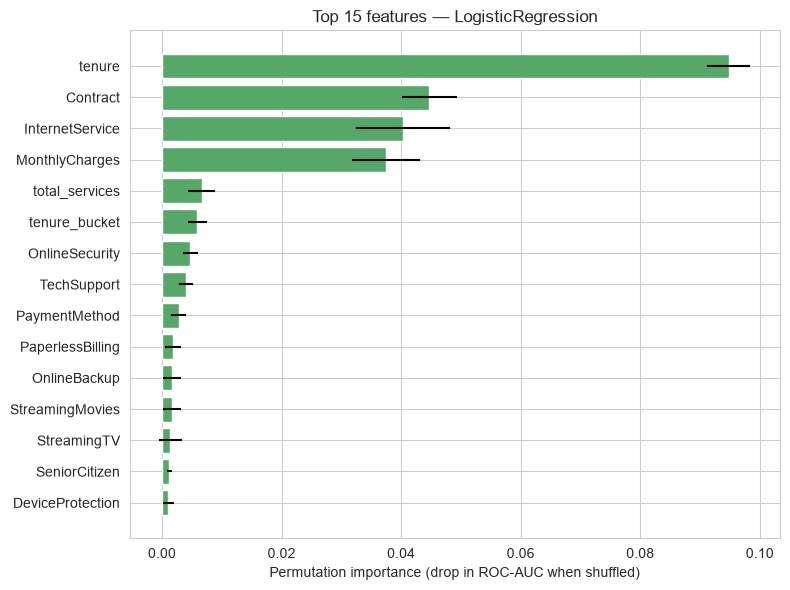

In [27]:
# Note: permutation_importance runs on the WHOLE pipeline, so it permutes the
# original (pre-encoding) columns of X_test, not the one-hot-expanded columns.
perm = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10,
                                random_state=RANDOM_STATE, scoring='roc_auc')

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
ax.barh(perm_df['feature'][::-1], perm_df['importance_mean'][::-1],
        xerr=perm_df['importance_std'][::-1], color='#55A868')
ax.set_xlabel("Permutation importance (drop in ROC-AUC when shuffled)")
ax.set_title(f"Top 15 features — {best_model_name}")
plt.tight_layout()
plt.show()


In [28]:
feature_names_out = best_pipeline.named_steps['prep'].get_feature_names_out()

if best_model_name == 'LogisticRegression':
    clf = best_pipeline.named_steps['clf']
    coefs = pd.DataFrame({
        'feature': feature_names_out,
        'coefficient': clf.coef_[0],
        'odds_ratio': np.exp(clf.coef_[0])
    }).sort_values('coefficient', ascending=False)
    print("Top features increasing churn odds:")
    print(coefs.head(8).to_string(index=False))
    print("\nTop features decreasing churn odds:")
    print(coefs.tail(8).to_string(index=False))
else:
    clf = best_pipeline.named_steps['clf']
    imp_df = pd.DataFrame({'feature': feature_names_out, 'importance': clf.feature_importances_}) \
                .sort_values('importance', ascending=False).head(15)
    print(imp_df.to_string(index=False))


Top features increasing churn odds:
                            feature  coefficient  odds_ratio
       cat__Contract_Month-to-month     0.679189    1.972278
   cat__InternetService_Fiber optic     0.673046    1.960199
          cat__PaperlessBilling_Yes     0.343071    1.409269
                num__total_services     0.337408    1.401311
            cat__tenure_bucket_4yr+     0.303853    1.355070
cat__PaymentMethod_Electronic check     0.211550    1.235592
             cat__OnlineSecurity_No     0.205508    1.228149
                cat__TechSupport_No     0.166659    1.181352

Top features decreasing churn odds:
                                feature  coefficient  odds_ratio
  cat__OnlineBackup_No internet service    -0.246030    0.781899
cat__OnlineSecurity_No internet service    -0.246030    0.781899
                cat__InternetService_No    -0.246030    0.781899
               cat__tenure_bucket_1-2yr    -0.398983    0.671002
                    num__MonthlyCharges    -0.668663 

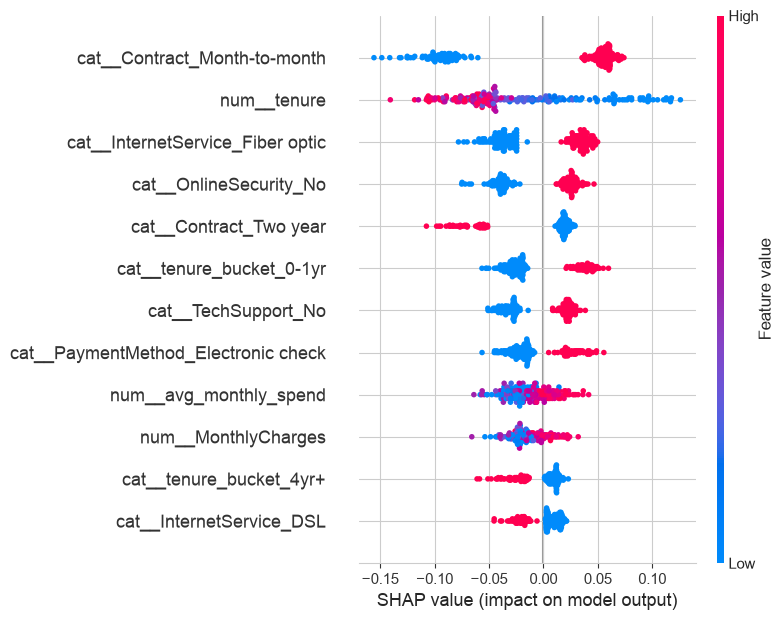

In [29]:
# Supplementary SHAP deep-dive on the Random Forest (per-customer explanation demo)
rf_pipe = fitted_pipelines['RandomForest']
X_test_transformed = rf_pipe.named_steps['prep'].transform(X_test)
rf_feature_names = rf_pipe.named_steps['prep'].get_feature_names_out()

explainer = shap.TreeExplainer(rf_pipe.named_steps['clf'])
sample = X_test_transformed[:200]
shap_values = explainer.shap_values(sample)

sv = shap_values[:, :, 1] if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3 else shap_values

shap.summary_plot(sv, sample, feature_names=rf_feature_names, show=False, max_display=12)
plt.tight_layout()
plt.show()


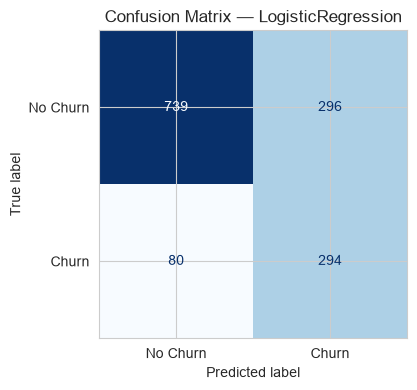

In [30]:
fig, ax = plt.subplots(figsize=(5,4))
best_pred = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn','Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()


## 8. Summary — Technique Decisions & Why

| Decision point | Chosen | Rejected alternative & why |
|---|---|---|
| Missing values | Conditional impute (`TotalCharges=0` where `tenure=0`) | Not mean/median-fill — would invent a spend history for never-billed customers |
| Multicollinearity | Drop `TotalCharges` (corr 0.9996 with tenure x MonthlyCharges) | Keeping it would destabilize Logistic Regression coefficients and split SHAP credit |
| Transformation | Log-consideration only for `TotalCharges` (dropped anyway) | `tenure`/`MonthlyCharges` are near-symmetric — blanket log-transform would add noise |
| Scaling | StandardScaler for Logistic Regression only | Trees are scale-invariant — scaling them is wasted, misleading effort |
| Encoding | One-hot (all categoricals, `drop='if_binary'`) | Not target encoding — extra leakage surface for zero benefit at only 2-4 categories/column |
| Feature creation | `tenure_bucket`, `total_services`, `avg_monthly_spend` (business/RFM-style) | Not polynomial/interaction expansion — risks sparsity for no proven benefit; trees already capture interactions |
| Feature selection | Chi-square filter | Not RFE — filter runs once, RFE retrains repeatedly, for a feature count that doesn't need it |
| Dimensionality reduction | Skipped entirely | Only ~25 features post-encoding — no curse-of-dimensionality problem, and PCA would destroy interpretability |
| Imbalance handling | `class_weight='balanced'` | Not SMOTE — 26.5% churn is moderate, not severe; avoids fabricating synthetic customer records |
| Interpretability | Permutation importance + SHAP (supplementary) | Model-agnostic, works regardless of which model wins |
| Leakage | Explicit "knowable at prediction time" checklist per feature | Direct application of the mindmap's own detection pattern |

**Next steps (outside this notebook):** wrap `../models/model.joblib` in a FastAPI `/predict` service, build a Streamlit UI on top of it, containerize with Docker, automate the Docker Hub push via GitHub Actions, and version this dataset + pipeline with DVC.


## 9. Feature Validation — `avg_monthly_spend` and Baseline Comparison

This section validates whether the engineered features add measurable value without changing the existing selected model.

In [31]:
# 9.1 Validate avg_monthly_spend against MonthlyCharges
avg_spend_corr = df_fe['avg_monthly_spend'].corr(df_fe['MonthlyCharges'])
avg_spend_diff = (df_fe['avg_monthly_spend'] - df_fe['MonthlyCharges']).abs()

print(f"Correlation: avg_monthly_spend vs MonthlyCharges = {avg_spend_corr:.4f}")
print(f"Median absolute difference = {avg_spend_diff.median():.4f}")
print(f"Mean absolute difference = {avg_spend_diff.mean():.4f}")

if abs(avg_spend_corr) >= 0.99:
    print("Finding: avg_monthly_spend is highly redundant with MonthlyCharges in this dataset.")
else:
    print("Finding: avg_monthly_spend is not almost identical to MonthlyCharges; continue with the ablation test below.")

Correlation: avg_monthly_spend vs MonthlyCharges = 0.9944
Median absolute difference = 1.1569
Mean absolute difference = 1.8077
Finding: avg_monthly_spend is highly redundant with MonthlyCharges in this dataset.


In [32]:
# 9.2 Ablation test: current feature set vs removing avg_monthly_spend
X_train_no_avg = X_train.drop(columns=['avg_monthly_spend'])
X_test_no_avg = X_test.drop(columns=['avg_monthly_spend'])

numeric_no_avg = ['tenure', 'MonthlyCharges', 'total_services', 'SeniorCitizen']
categorical_no_avg = [c for c in X_train_no_avg.columns if c not in numeric_no_avg]

prep_scaled_no_avg = ColumnTransformer([
    ('num', StandardScaler(), numeric_no_avg),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_no_avg)
])
prep_tree_no_avg = ColumnTransformer([
    ('num', 'passthrough', numeric_no_avg),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_no_avg)
])

def build_selected_model(model_name, prep_scaled, prep_tree):
    if model_name == 'LogisticRegression':
        model_params = {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 1000}
        prep = prep_scaled
        clf = LogisticRegression(**model_params)
    elif model_name == 'RandomForest':
        model_params = {'n_estimators': 300, 'max_depth': 12, 'class_weight': 'balanced', 'random_state': RANDOM_STATE}
        prep = prep_tree
        clf = RandomForestClassifier(**model_params)
    else:
        scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
        model_params = {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05,
                        'scale_pos_weight': scale_pos_weight, 'random_state': RANDOM_STATE}
        prep = prep_tree
        clf = XGBClassifier(**model_params, eval_metric='logloss')
    return Pipeline([('prep', prep), ('clf', clf)])

ablation_pipeline = build_selected_model(best_model_name, prep_scaled_no_avg, prep_tree_no_avg)
ablation_pipeline.fit(X_train_no_avg, y_train)
ablation_proba = ablation_pipeline.predict_proba(X_test_no_avg)[:, 1]
ablation_pred = ablation_pipeline.predict(X_test_no_avg)
ablation_metrics = evaluate(y_test, ablation_pred, ablation_proba)

current_metrics = results_df.loc[best_model_name].to_dict()
ablation_comparison = pd.DataFrame({
    'Current feature set': current_metrics,
    'Without avg_monthly_spend': ablation_metrics
}).loc[['roc_auc', 'recall', 'precision', 'f1']]

display(ablation_comparison.style.format('{:.4f}'))
print("Decision: retain avg_monthly_spend only if it provides a meaningful performance benefit.")
print("The comparison above should be interpreted together with the correlation analysis.")

,Current feature set,Without avg_monthly_spend
roc_auc,0.8412,0.8413
recall,0.7861,0.7888
precision,0.4983,0.4975
f1,0.6100,0.6101


Decision: retain avg_monthly_spend only if it provides a meaningful performance benefit.
The comparison above should be interpreted together with the correlation analysis.


In [33]:
# 9.3 Baseline vs feature-engineered model
# Baseline uses the original customer features (after fixing TotalCharges and removing customerID/Churn),
# while the feature-engineered model is the existing selected pipeline.
X_baseline = df.drop(columns=['customerID', 'Churn']).copy()
y_baseline = df['Churn'].map({'Yes': 1, 'No': 0})

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_baseline, y_baseline, test_size=0.2, stratify=y_baseline, random_state=RANDOM_STATE
)

baseline_numeric = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
baseline_categorical = [c for c in Xb_train.columns if c not in baseline_numeric]

baseline_scaled = ColumnTransformer([
    ('num', StandardScaler(), baseline_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), baseline_categorical)
])
baseline_tree = ColumnTransformer([
    ('num', 'passthrough', baseline_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), baseline_categorical)
])

baseline_pipeline = build_selected_model(best_model_name, baseline_scaled, baseline_tree)
baseline_pipeline.fit(Xb_train, yb_train)
baseline_proba = baseline_pipeline.predict_proba(Xb_test)[:, 1]
baseline_pred = baseline_pipeline.predict(Xb_test)
baseline_metrics = evaluate(yb_test, baseline_pred, baseline_proba)

feature_engineered_metrics = results_df.loc[best_model_name].to_dict()
fe_comparison = pd.DataFrame({
    'Baseline (raw features)': baseline_metrics,
    'Feature-engineered': feature_engineered_metrics
}).loc[['roc_auc', 'recall', 'precision', 'f1']]

display(fe_comparison.style.format('{:.4f}'))
print("No model replacement is performed from this experiment; it is only a controlled feature-engineering validation.")

,Baseline (raw features),Feature-engineered
roc_auc,0.8417,0.8412
recall,0.7834,0.7861
precision,0.5052,0.4983
f1,0.6143,0.6100


No model replacement is performed from this experiment; it is only a controlled feature-engineering validation.


## 10. Business Outputs for the Churn Product

The following outputs are derived from the existing churn model. Risk level is a business rule, and Estimated Revenue Exposure is a probability-weighted annual revenue proxy — neither is a second ML prediction.

In [34]:
# 10.1 Reusable business-output functions
RISK_THRESHOLDS = {'low_max': 0.40, 'medium_max': 0.70}

def get_risk_level(churn_probability):
    if churn_probability < RISK_THRESHOLDS['low_max']:
        return 'Low'
    elif churn_probability <= RISK_THRESHOLDS['medium_max']:
        return 'Medium'
    return 'High'

def estimated_revenue_exposure(churn_probability, monthly_charges):
    return float(churn_probability * monthly_charges * 12)

print("Risk rules: <0.40 = Low, 0.40–0.70 = Medium, >0.70 = High")
print("Estimated Revenue Exposure = churn_probability × MonthlyCharges × 12")

Risk rules: <0.40 = Low, 0.40–0.70 = Medium, >0.70 = High
Estimated Revenue Exposure = churn_probability × MonthlyCharges × 12


In [35]:
# 10.2 Local, model-supported risk drivers for one actual test customer
def get_local_risk_drivers(pipeline, customer_row, top_n=3):
    prep = pipeline.named_steps['prep']
    clf = pipeline.named_steps['clf']
    transformed = prep.transform(customer_row)
    feature_names = prep.get_feature_names_out()

    if hasattr(clf, 'coef_'):
        contributions = np.asarray(transformed)[0] * clf.coef_[0]
    else:
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(transformed)
            
        if isinstance(shap_values, list):
            contributions = np.asarray(shap_values[1])[0]
        else:
            shap_array = np.asarray(shap_values)
            if shap_array.ndim == 3:
                contributions = shap_array[0, :, 1]
            else:
                contributions = shap_array[0]

    grouped = {}
    labels = {}
    categorical_original = set(pipeline.named_steps['prep'].transformers_[1][2])
            
    for name, contribution in zip(feature_names, contributions):
        if name.startswith('num__'):
            raw_name = name.replace('num__', '', 1)
            label = raw_name
        elif name.startswith('cat__'):
            remainder = name.replace('cat__', '', 1)
            raw_name = next((c for c in categorical_original if remainder == c or remainder.startswith(c + '_')), remainder)
            category = remainder[len(raw_name) + 1:] if remainder.startswith(raw_name + '_') else ''
            label = f'{raw_name} = {category}' if category else raw_name
        else:
            raw_name = name
            label = name
            
        grouped.setdefault(raw_name, []).append((label, float(contribution)))

    ranked = []
    for raw_name, parts in grouped.items():
        strongest_label, strongest_value = max(parts, key=lambda x: abs(x[1]))
        total_value = sum(v for _, v in parts)
        ranked.append((strongest_label, total_value, strongest_value))

    ranked.sort(key=lambda x: abs(x[1]), reverse=True)
    return ranked[:top_n]

# Use one actual customer from the held-out test set.
example_customer = X_test.iloc[[0]].copy()
example_probability = float(best_pipeline.predict_proba(example_customer)[0, 1])
example_prediction = int(best_pipeline.predict(example_customer)[0])
example_monthly_charges = float(example_customer['MonthlyCharges'].iloc[0])
example_risk = get_risk_level(example_probability)
example_exposure = estimated_revenue_exposure(example_probability, example_monthly_charges)
example_drivers = get_local_risk_drivers(best_pipeline, example_customer, top_n=3)

print(f"Churn Prediction: {'Yes' if example_prediction == 1 else 'No'}")
print(f"Churn Probability: {example_probability:.1%}")
print(f"Risk Level: {example_risk}")
print(f"Estimated Revenue Exposure: ₹{example_exposure:,.2f}/year")
print("\nKey Risk Drivers:")
for i, (label, total_value, _) in enumerate(example_drivers, 1):
    direction = 'increases' if total_value > 0 else 'reduces'
    print(f"{i}. {label} ({direction} churn contribution)")

Churn Prediction: No
Churn Probability: 10.1%
Risk Level: Low
Estimated Revenue Exposure: ₹138.62/year

Key Risk Drivers:
1. tenure (reduces churn contribution)
2. MonthlyCharges (reduces churn contribution)
3. Contract = Two year (reduces churn contribution)


**Estimated Revenue Exposure note:** This is a probability-weighted annual revenue proxy based on the customer's current monthly charge, assuming 12 months of potential future billing. It is not a separate ML prediction of actual revenue loss.